# ==============================================================================
#                    RETAIL DEMAND FORECASTING USING MACHINE LEARNING
#
#                           NOTEBOOK 1
#
#                    DATA PREPROCESSING & FEATURE ENGINEERING
#
# Author      : Aniket Sharma
# Course      : MCA
# Project     : Major Project
#
# ==============================================================================

In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 1

### Data Preprocessing & Feature Engineering

---

### Objectives

- Load Dataset
- Explore Dataset
- Handle Missing Values
- Handle Duplicate Values
- Feature Engineering
- Detect Outliers
- Remove Outliers
- Encode Categorical Features
- Scale Numerical Features
- Train-Test Split
- Export Clean Dataset

Target Variable : **Demand**

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment only if required

# %pip install pandas
# %pip install numpy
# %pip install matplotlib
# %pip install seaborn
# %pip install plotly
# %pip install scikit-learn
# %pip install xgboost
# %pip install lightgbm
# %pip install catboost
# %pip install missingno
# %pip install openpyxl
# %pip install statsmodels
# %pip install joblib

In [2]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import missingno as msno

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"]=(12,6)

pd.set_option("display.max_columns",None)

pd.set_option("display.max_rows",100)

pd.set_option("display.max_colwidth",None)

pd.set_option("display.float_format","{:.2f}".format)

In [4]:
# ==============================================================================
# PROJECT DIRECTORY
# ==============================================================================

PROJECT_DIR = os.getcwd()

print("Project Directory")

print(PROJECT_DIR)

Project Directory
c:\Users\asus\Desktop\RETAIL\notebook


In [7]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\Retail_Demand_Forecasting_10000.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [9]:
# ==============================================================================
# DISPLAY SHAPE
# ==============================================================================

print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

Rows : 10000
Columns : 18


In [10]:
# ==============================================================================
# DISPLAY FIRST 5 RECORDS
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales
0,2023-01-01,41,1029,Electronics,East,0,0,Sunny,32.10,107.07,287.06,3.78,452,111.98,102.88,14,278,27
1,2023-01-02,46,1167,Sports,West,0,1,Cloudy,18.30,114.77,271.06,4.44,452,713.49,664.33,48,192,54
2,2023-01-03,7,1024,Furniture,North,1,1,Cloudy,17.90,81.74,235.13,4.12,964,788.14,796.34,40,336,146
3,2023-01-04,13,1181,Electronics,North,0,1,Sunny,35.70,114.66,225.62,7.08,874,761.42,741.65,13,363,135
4,2023-01-05,18,1180,Sports,North,0,0,Sunny,23.90,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0


In [11]:
# ==============================================================================
# DISPLAY LAST 5 RECORDS
# ==============================================================================

df.tail()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales
9995,2024-05-20,22,1006,Sports,South,0,1,Cloudy,31.60,114.27,295.34,8.98,426,383.82,420.18,2,119,48
9996,2024-05-21,35,1177,Electronics,East,0,0,Cloudy,21.40,115.54,263.00,4.79,989,1590.48,1480.56,4,418,57
9997,2024-05-22,41,1063,Grocery,East,1,0,Cloudy,21.40,88.18,244.49,8.26,150,1601.22,1645.62,50,77,0
9998,2024-05-23,41,1137,Grocery,North,1,0,Cloudy,17.50,91.01,250.85,10.81,66,243.18,246.78,24,230,40
9999,2024-05-24,16,1102,Clothing,West,1,1,Sunny,13.70,119.43,270.46,8.50,190,1140.42,1207.26,6,436,199


In [12]:
# ==============================================================================
# RANDOM SAMPLE
# ==============================================================================

df.sample(10)

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales
1532,2023-03-14,28,1176,Furniture,East,1,0,Cloudy,26.20,118.84,282.76,10.72,475,350.62,343.25,7,45,8
6778,2023-07-28,34,1051,Sports,West,1,0,Rainy,18.40,85.34,257.41,10.57,796,766.84,728.80,47,112,6
7537,2023-08-26,22,1198,Grocery,East,0,0,Sunny,15.40,102.88,249.45,7.11,156,891.52,923.57,37,123,6
1237,2024-05-22,43,1072,Sports,South,1,1,Rainy,18.00,107.21,286.84,7.48,135,1019.58,1048.70,10,465,224
6270,2024-03-06,6,1022,Toys,West,1,0,Cloudy,24.40,90.39,250.43,3.65,892,282.14,274.33,22,121,0
7061,2024-05-06,22,1143,Toys,North,1,1,Rainy,28.70,83.57,215.37,11.16,523,1887.52,1726.27,49,284,115
9220,2024-04-05,39,1094,Furniture,West,1,0,Cloudy,18.00,115.50,274.69,5.07,701,176.59,168.19,5,355,82
4336,2024-11-17,2,1003,Furniture,East,0,0,Rainy,26.10,113.06,189.83,3.31,754,1960.53,2116.88,20,433,73
7621,2023-11-18,27,1024,Clothing,North,0,0,Rainy,28.30,90.93,227.17,6.37,705,382.11,369.00,9,451,50
1810,2023-12-17,26,1179,Beauty,East,0,0,Cloudy,30.70,108.42,278.52,6.14,475,1490.83,1617.70,9,431,45


In [13]:
# ==============================================================================
# DATA INFORMATION
# ==============================================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              10000 non-null  str    
 1   Store_ID          10000 non-null  int64  
 2   Product_ID        10000 non-null  int64  
 3   Category          10000 non-null  str    
 4   Region            10000 non-null  str    
 5   Holiday           10000 non-null  int64  
 6   Promotion         10000 non-null  int64  
 7   Weather           10000 non-null  str    
 8   Temperature       10000 non-null  float64
 9   Fuel_Price        10000 non-null  float64
 10  CPI               10000 non-null  float64
 11  Unemployment      10000 non-null  float64
 12  Inventory         10000 non-null  int64  
 13  Price             10000 non-null  float64
 14  Competitor_Price  10000 non-null  float64
 15  Discount          10000 non-null  int64  
 16  Customers         10000 non-null  int64  
 17  Sales

In [14]:
# ==============================================================================
# COLUMN NAMES
# ==============================================================================

df.columns.tolist()

['Date',
 'Store_ID',
 'Product_ID',
 'Category',
 'Region',
 'Holiday',
 'Promotion',
 'Weather',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Inventory',
 'Price',
 'Competitor_Price',
 'Discount',
 'Customers',
 'Sales']

In [15]:
# ==============================================================================
# SHAPE
# ==============================================================================

print(df.shape)

(10000, 18)


In [16]:
# ==============================================================================
# DATA TYPES
# ==============================================================================

df.dtypes

Date                    str
Store_ID              int64
Product_ID            int64
Category                str
Region                  str
Holiday               int64
Promotion             int64
Weather                 str
Temperature         float64
Fuel_Price          float64
CPI                 float64
Unemployment        float64
Inventory             int64
Price               float64
Competitor_Price    float64
Discount              int64
Customers             int64
Sales                 int64
dtype: object

In [17]:
# ==============================================================================
# NUMERICAL FEATURES
# ==============================================================================

num_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

num_cols

['Store_ID',
 'Product_ID',
 'Holiday',
 'Promotion',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Inventory',
 'Price',
 'Competitor_Price',
 'Discount',
 'Customers',
 'Sales']

In [18]:
# ==============================================================================
# CATEGORICAL FEATURES
# ==============================================================================

cat_cols = df.select_dtypes(
    include="object"
).columns.tolist()

cat_cols

['Date', 'Category', 'Region', 'Weather']

In [19]:
# ==============================================================================
# STATISTICAL SUMMARY
# ==============================================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store_ID,10000.00,25.45,14.49,1.00,13.00,25.00,38.00,50.00
Product_ID,10000.00,1101.83,57.77,1001.00,1052.00,1104.00,1152.00,1200.00
Holiday,10000.00,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Promotion,10000.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
Temperature,10000.00,25.21,8.69,10.00,17.80,25.20,32.90,40.00
Fuel_Price,10000.00,99.95,11.55,80.00,90.00,99.77,110.06,120.00
CPI,10000.00,239.88,34.36,180.01,210.21,240.00,269.17,299.98
Unemployment,10000.00,7.51,2.60,3.00,5.25,7.50,9.80,12.00
Inventory,10000.00,507.42,287.98,20.00,254.00,505.00,760.25,1000.00
Price,10000.00,1018.96,559.16,50.33,529.90,1024.86,1496.50,1999.92


In [20]:
# ==============================================================================
# CATEGORICAL SUMMARY
# ==============================================================================

df.describe(include="object").T

,count,unique,top,freq
Date,10000,730,2023-01-01,14
Category,10000,7,Toys,1493
Region,10000,4,West,2551
Weather,10000,3,Rainy,3405


In [21]:
# ==============================================================================
# MEMORY USAGE
# ==============================================================================

df.memory_usage(deep=True)

Index                  132
Date                180000
Store_ID             80000
Product_ID           80000
Category            152612
Region              124976
Holiday              80000
Promotion            80000
Weather             133269
Temperature          80000
Fuel_Price           80000
CPI                  80000
Unemployment         80000
Inventory            80000
Price                80000
Competitor_Price     80000
Discount             80000
Customers            80000
Sales                80000
dtype: int64

In [22]:
# ==============================================================================
# TOTAL MEMORY USAGE
# ==============================================================================

print(
    round(
        df.memory_usage(deep=True).sum()/1024**2,
        2
    ),
    "MB"
)

1.63 MB


In [23]:
# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

df.isnull().sum()

Date                0
Store_ID            0
Product_ID          0
Category            0
Region              0
Holiday             0
Promotion           0
Weather             0
Temperature         0
Fuel_Price          0
CPI                 0
Unemployment        0
Inventory           0
Price               0
Competitor_Price    0
Discount            0
Customers           0
Sales               0
dtype: int64

In [24]:
# ==============================================================================
# MISSING VALUE PERCENTAGE
# ==============================================================================

(
    df.isnull().sum()/len(df)
)*100

Date               0.00
Store_ID           0.00
Product_ID         0.00
Category           0.00
Region             0.00
Holiday            0.00
Promotion          0.00
Weather            0.00
Temperature        0.00
Fuel_Price         0.00
CPI                0.00
Unemployment       0.00
Inventory          0.00
Price              0.00
Competitor_Price   0.00
Discount           0.00
Customers          0.00
Sales              0.00
dtype: float64

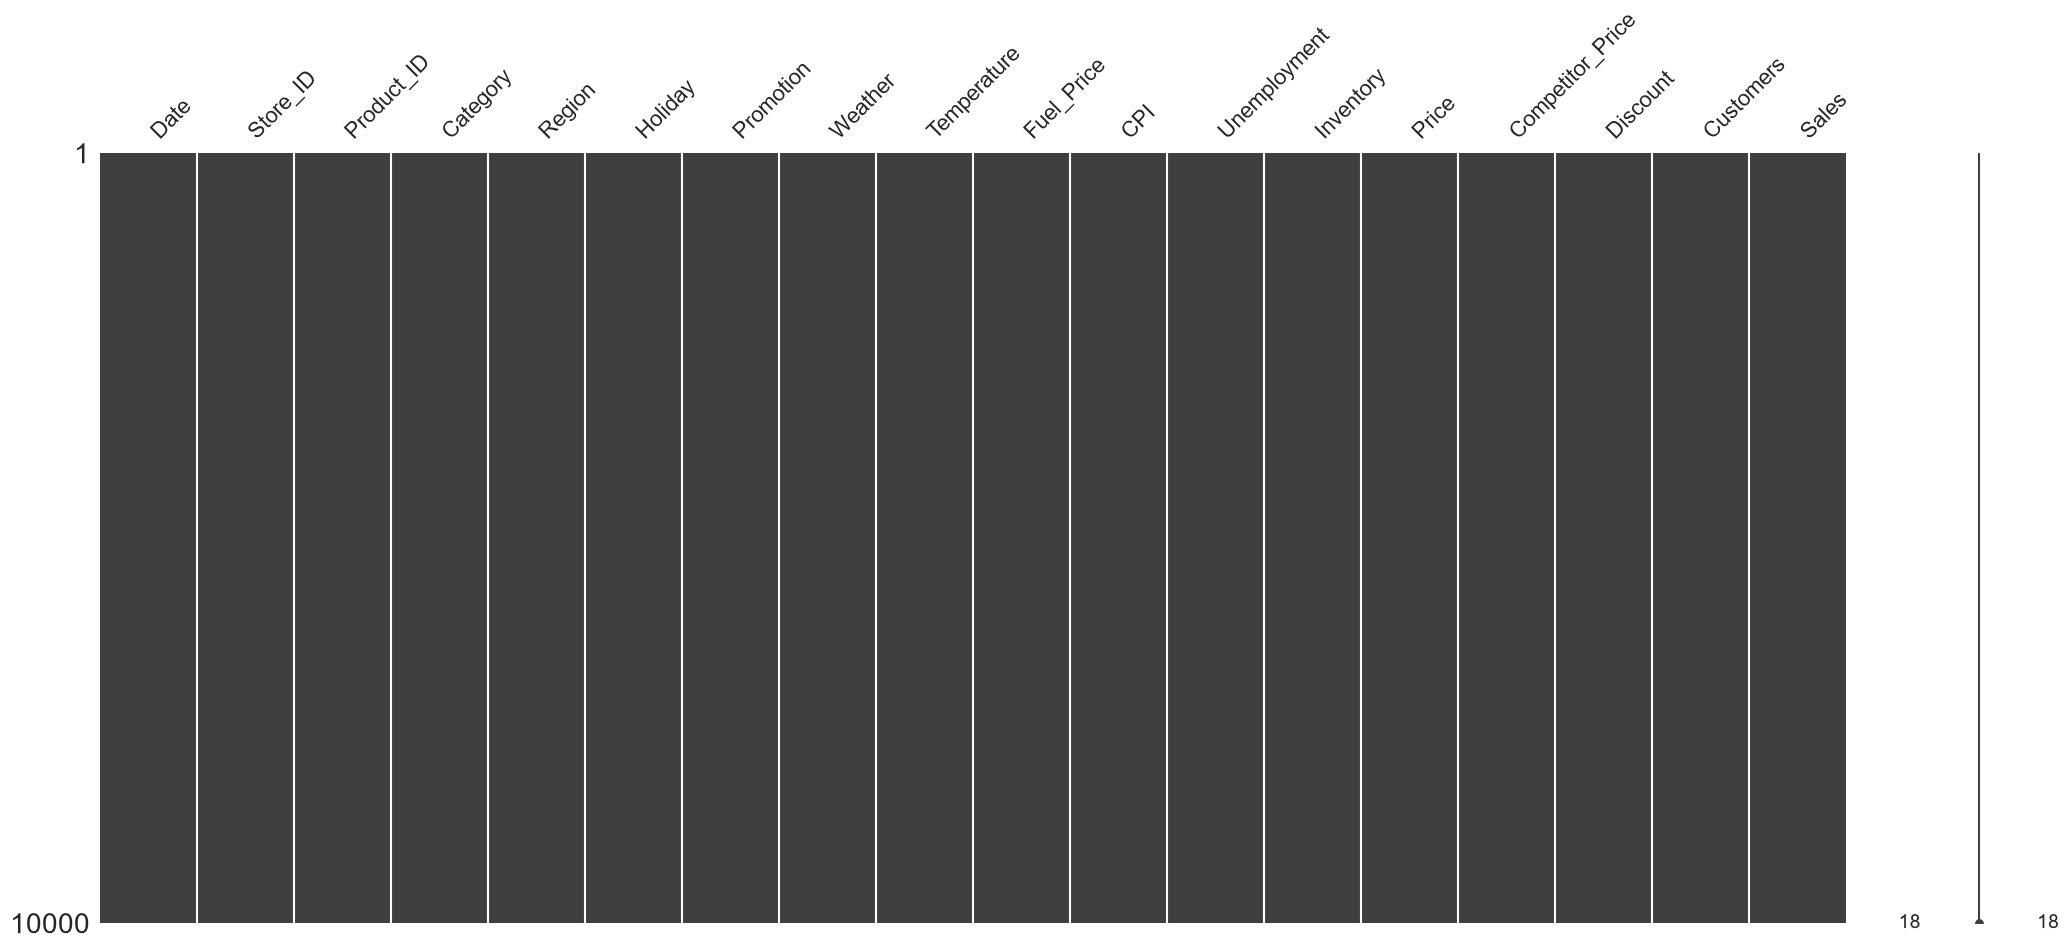

In [25]:
# ==============================================================================
# VISUALIZE MISSING VALUES
# ==============================================================================

msno.matrix(df)

plt.show()

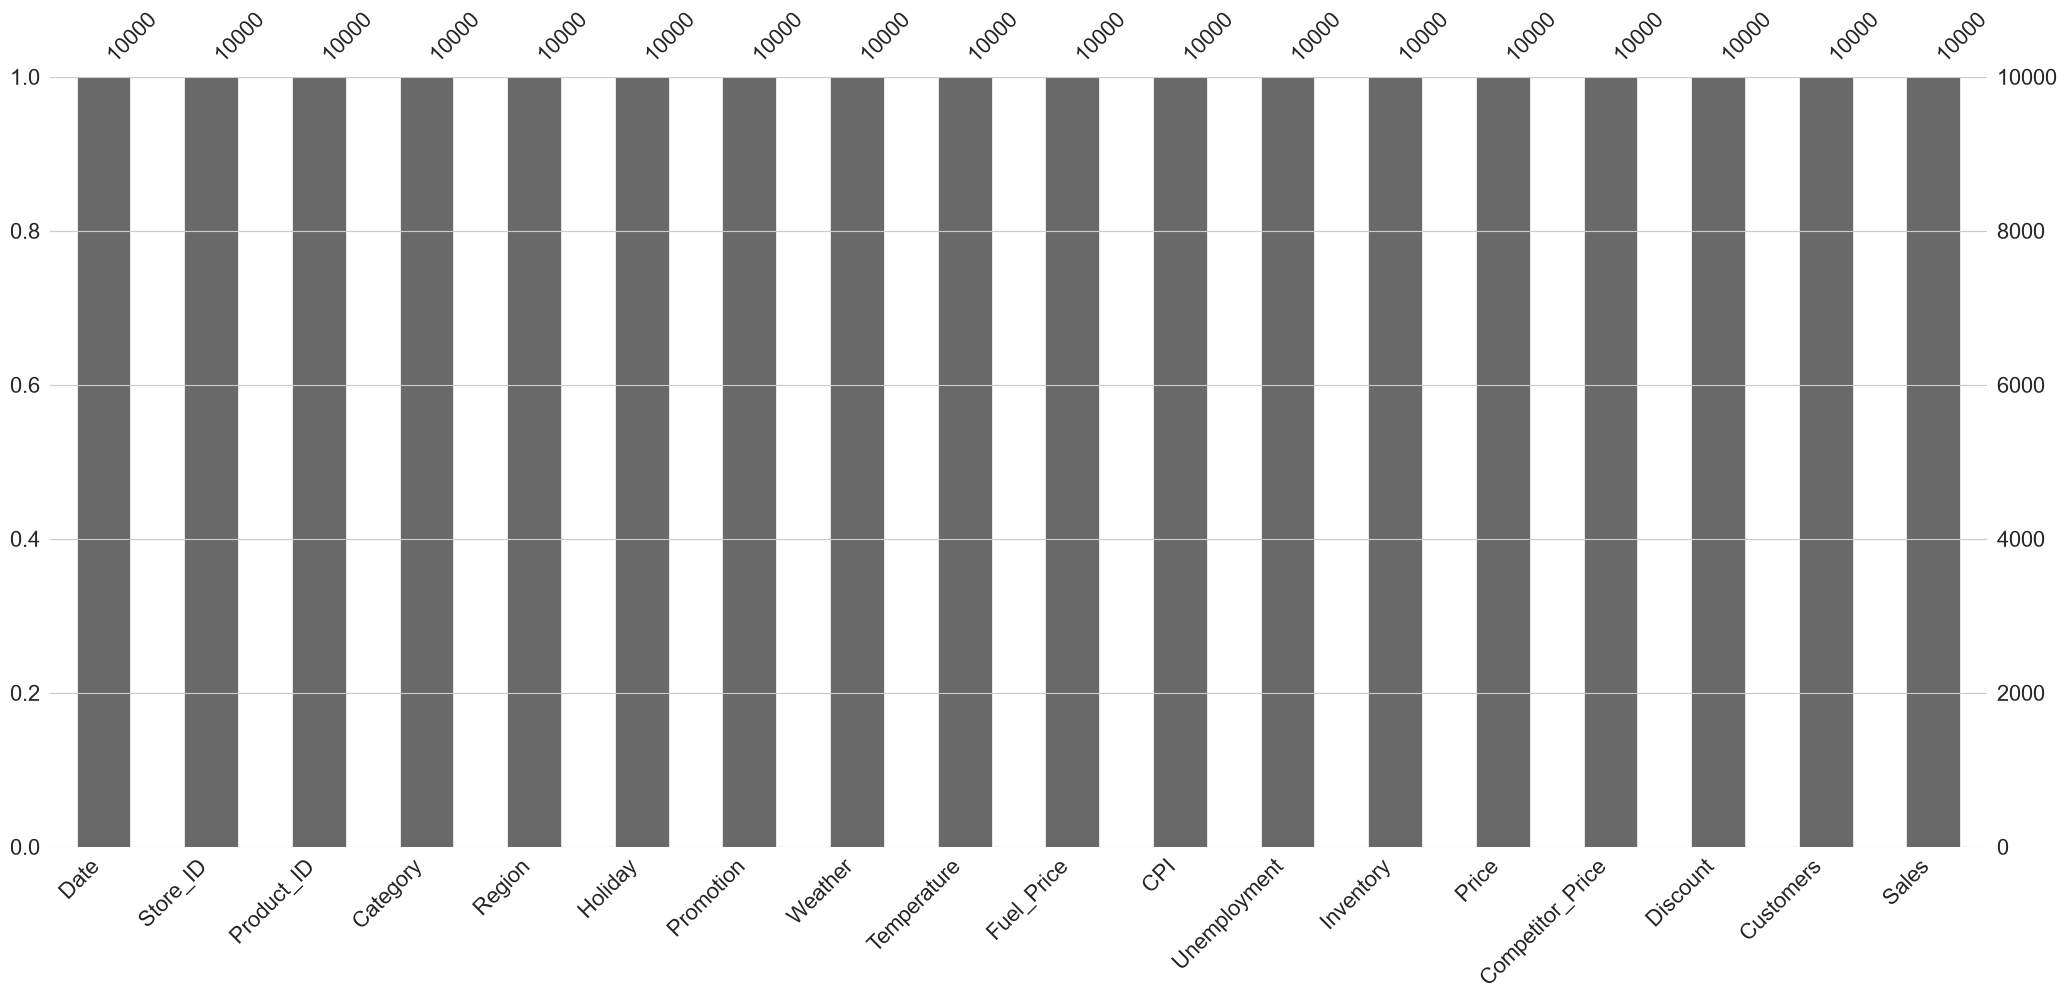

In [26]:
# ==============================================================================
# MISSING VALUE BAR GRAPH
# ==============================================================================

msno.bar(df)

plt.show()

In [27]:
# ==============================================================================
# CHECK DUPLICATE RECORDS
# ==============================================================================

duplicate_count = df.duplicated().sum()

print("Total Duplicate Records :", duplicate_count)

Total Duplicate Records : 0


In [28]:
# ==============================================================================
# REMOVE DUPLICATE RECORDS
# ==============================================================================

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates")

print(df.shape)

Dataset Shape After Removing Duplicates
(10000, 18)


In [29]:
# ==============================================================================
# CREATE BACKUP OF ORIGINAL DATASET
# ==============================================================================

df_backup = df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [31]:
# ==============================================================================
# RENAME COLUMN NAMES
# ==============================================================================

df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
)

print(df.columns.tolist())

['Date', 'Store_ID', 'Product_ID', 'Category', 'Region', 'Holiday', 'Promotion', 'Weather', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Sales']


In [32]:
# ==============================================================================
# CONVERT DATE COLUMN
# ==============================================================================

df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].head())

0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: Date, dtype: datetime64[us]


In [33]:
# ==============================================================================
# CREATE YEAR FEATURE
# ==============================================================================

df["Year"] = df["Date"].dt.year

In [34]:
# ==============================================================================
# CREATE MONTH FEATURE
# ==============================================================================

df["Month"] = df["Date"].dt.month

In [35]:
# ==============================================================================
# CREATE DAY FEATURE
# ==============================================================================

df["Day"] = df["Date"].dt.day

In [36]:
# ==============================================================================
# CREATE WEEK FEATURE
# ==============================================================================

df["Week"] = (
    df["Date"]
      .dt
      .isocalendar()
      .week
      .astype(int)
)

In [37]:
# ==============================================================================
# CREATE QUARTER FEATURE
# ==============================================================================

df["Quarter"] = df["Date"].dt.quarter

In [38]:
# ==============================================================================
# CREATE DAY NAME FEATURE
# ==============================================================================

df["Day_Name"] = df["Date"].dt.day_name()

In [39]:
# ==============================================================================
# CREATE MONTH NAME FEATURE
# ==============================================================================

df["Month_Name"] = df["Date"].dt.month_name()

In [40]:
# ==============================================================================
# CREATE WEEKEND FEATURE
# ==============================================================================

df["Weekend"] = (
    df["Day_Name"]
      .isin(["Saturday", "Sunday"])
      .astype(int)
)

In [41]:
# ==============================================================================
# CREATE SEASON FEATURE
# ==============================================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [44]:
# ==============================================================================
# INVENTORY PER CUSTOMER
# ==============================================================================

df["Inventory_Per_Customer"] = (
    df["Inventory"] /
    (df["Customers"] + 1)
)

print("Inventory_Per_Customer feature created successfully.")

Inventory_Per_Customer feature created successfully.


In [46]:
# ==============================================================================
# PRICE DIFFERENCE
# ==============================================================================

df["Price_Difference"] = (
    df["Price"] -
    df["Competitor_Price"]
)

print("Price_Difference Feature Created Successfully")

Price_Difference Feature Created Successfully


In [47]:
# ==============================================================================
# DISCOUNT AMOUNT
# ==============================================================================

df["Discount_Amount"] = (
    df["Price"] *
    df["Discount"] / 100
)

print("Discount_Amount Feature Created Successfully")

Discount_Amount Feature Created Successfully


In [48]:
# ==============================================================================
# FINAL SELLING PRICE
# ==============================================================================

df["Final_Price"] = (
    df["Price"] -
    df["Discount_Amount"]
)

print("Final_Price Feature Created Successfully")

Final_Price Feature Created Successfully


In [49]:
# ==============================================================================
# SALES PER CUSTOMER
# ==============================================================================

df["Sales_Per_Customer"] = (
    df["Sales"] /
    (df["Customers"] + 1)
)

print("Sales_Per_Customer Feature Created Successfully")

Sales_Per_Customer Feature Created Successfully


In [50]:
# ==============================================================================
# PROMOTION IMPACT
# ==============================================================================

df["Promotion_Impact"] = (
    df["Promotion"] *
    df["Discount"]
)

print("Promotion_Impact Feature Created Successfully")

Promotion_Impact Feature Created Successfully


In [51]:
# ==============================================================================
# CHECK NEW FEATURES
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,Electronics,East,0,0,Sunny,32.10,107.07,287.06,3.78,452,111.98,102.88,14,278,27,2023,1,1,52,1,Sunday,January,1,Winter,1.62,9.10,15.68,96.30,0.10,0
1,2023-01-02,46,1167,Sports,West,0,1,Cloudy,18.30,114.77,271.06,4.44,452,713.49,664.33,48,192,54,2023,1,2,1,1,Monday,January,0,Winter,2.34,49.16,342.48,371.01,0.28,48
2,2023-01-03,7,1024,Furniture,North,1,1,Cloudy,17.90,81.74,235.13,4.12,964,788.14,796.34,40,336,146,2023,1,3,1,1,Tuesday,January,0,Winter,2.86,-8.20,315.26,472.88,0.43,40
3,2023-01-04,13,1181,Electronics,North,0,1,Sunny,35.70,114.66,225.62,7.08,874,761.42,741.65,13,363,135,2023,1,4,1,1,Wednesday,January,0,Winter,2.40,19.77,98.98,662.44,0.37,13
4,2023-01-05,18,1180,Sports,North,0,0,Sunny,23.90,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0,2023,1,5,1,1,Thursday,January,0,Winter,4.98,-94.97,678.65,706.35,0.00,0


In [52]:
# ==============================================================================
# DATASET SHAPE AFTER FEATURE ENGINEERING
# ==============================================================================

print("Dataset Shape :", df.shape)

Dataset Shape : (10000, 33)


In [53]:
# ==============================================================================
# DISPLAY NUMERICAL FEATURES
# ==============================================================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical Features")

print(numerical_columns)

Numerical Features
['Store_ID', 'Product_ID', 'Holiday', 'Promotion', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Sales', 'Week', 'Weekend', 'Inventory_Per_Customer', 'Price_Difference', 'Discount_Amount', 'Final_Price', 'Sales_Per_Customer', 'Promotion_Impact']


In [54]:
# ==============================================================================
# DISPLAY CATEGORICAL FEATURES
# ==============================================================================

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Features")

print(categorical_columns)

Categorical Features
['Category', 'Region', 'Weather', 'Day_Name', 'Month_Name', 'Season']


In [55]:
# ==============================================================================
# SAVE FEATURE ENGINEERED DATASET
# ==============================================================================

df.to_csv(
    "../dataset/retail_feature_engineered.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully")

Feature Engineered Dataset Saved Successfully


In [56]:
# ==============================================================================
# TARGET VARIABLE
# ==============================================================================

TARGET = "Sales"

print("Target Variable :", TARGET)

Target Variable : Sales


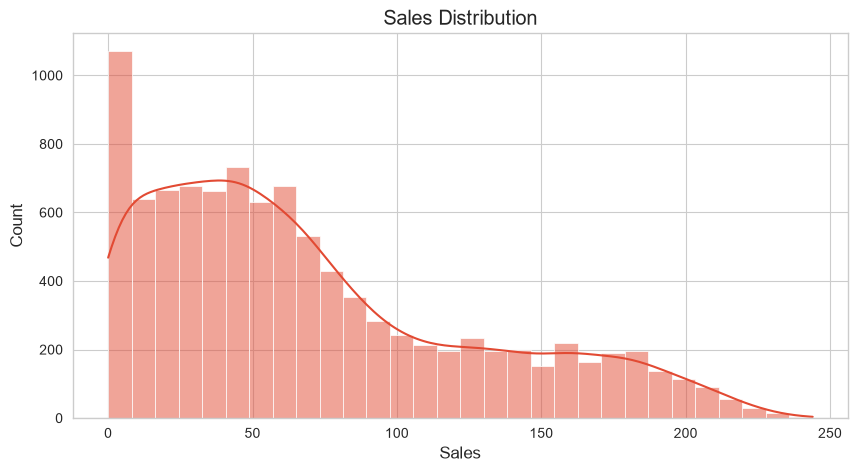

In [57]:
# ==============================================================================
# CHECK TARGET DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(df[TARGET], bins=30, kde=True)

plt.title("Sales Distribution")

plt.show()

In [58]:
# ==============================================================================
# CORRELATION MATRIX
# ==============================================================================

corr_matrix = df.corr(numeric_only=True)

corr_matrix

,Store_ID,Product_ID,Holiday,Promotion,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Weekend,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
Store_ID,1.00,0.00,-0.00,-0.01,0.00,0.00,0.00,-0.00,-0.01,0.01,0.01,-0.00,0.01,0.01,0.01,0.01,-0.00,0.01,0.01,-0.01,-0.02,0.01,0.00,0.01,-0.01,-0.00
Product_ID,0.00,1.00,-0.00,-0.02,-0.02,-0.02,0.02,0.00,0.01,0.00,0.01,-0.02,-0.02,-0.03,-0.01,-0.01,0.00,-0.01,-0.01,-0.01,0.02,-0.01,-0.01,0.01,-0.02,-0.02
Holiday,-0.00,-0.00,1.00,-0.00,0.00,0.01,0.01,-0.01,0.00,-0.01,-0.01,-0.00,0.00,0.12,0.00,0.00,0.00,0.00,-0.00,0.01,-0.00,0.00,-0.01,-0.01,0.16,-0.00
Promotion,-0.01,-0.02,-0.00,1.00,0.01,-0.00,-0.01,-0.01,0.00,0.01,0.01,-0.01,-0.01,0.56,0.01,0.01,-0.02,0.01,0.00,0.00,0.00,0.00,-0.01,0.01,0.80,0.76
Temperature,0.00,-0.02,0.00,0.01,1.00,0.02,0.01,-0.01,-0.01,-0.00,-0.00,-0.01,0.02,0.01,-0.01,0.00,-0.01,0.00,-0.00,0.01,0.00,0.01,-0.00,-0.00,0.01,0.01
Fuel_Price,0.00,-0.02,0.01,-0.00,0.02,1.00,-0.01,0.01,-0.02,0.01,0.00,-0.01,-0.00,-0.00,-0.01,-0.01,-0.00,-0.01,-0.01,-0.01,-0.01,0.01,-0.00,0.01,-0.01,-0.01
CPI,0.00,0.02,0.01,-0.01,0.01,-0.01,1.00,-0.01,-0.01,-0.02,-0.02,-0.00,-0.01,-0.01,0.02,-0.01,-0.00,-0.01,-0.01,-0.01,-0.00,0.01,-0.01,-0.02,-0.01,-0.02
Unemployment,-0.00,0.00,-0.01,-0.01,-0.01,0.01,-0.01,1.00,0.01,0.01,0.01,-0.01,-0.02,-0.02,0.01,-0.01,0.00,-0.01,-0.01,0.02,0.02,0.00,-0.00,0.01,-0.01,-0.02
Inventory,-0.01,0.01,0.00,0.00,-0.01,-0.02,-0.01,0.01,1.00,-0.01,-0.01,0.00,0.00,-0.00,-0.00,-0.01,-0.02,-0.01,-0.01,-0.00,0.41,-0.00,-0.01,-0.01,0.00,-0.01
Price,0.01,0.00,-0.01,0.01,-0.00,0.01,-0.02,0.01,-0.01,1.00,0.99,0.00,0.01,0.01,-0.00,0.01,0.01,0.01,0.01,-0.01,-0.01,0.00,0.63,0.92,-0.00,0.00


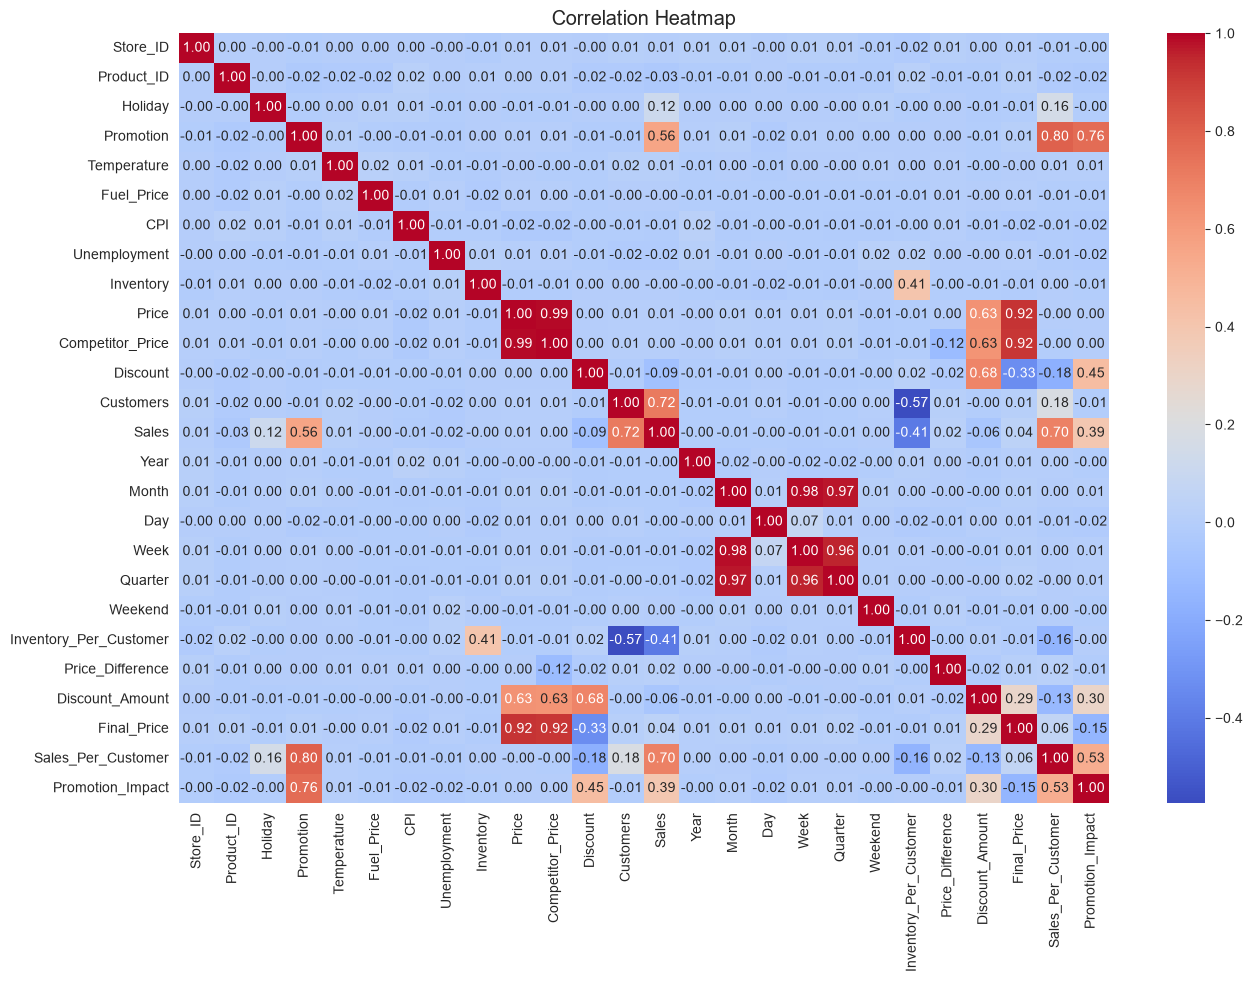

In [59]:
# ==============================================================================
# CORRELATION HEATMAP
# ==============================================================================

plt.figure(figsize=(15,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [60]:
# ==============================================================================
# SALES CORRELATION
# ==============================================================================

corr_matrix["Sales"].sort_values(ascending=False)

Sales                     1.00
Customers                 0.72
Sales_Per_Customer        0.70
Promotion                 0.56
Promotion_Impact          0.39
Holiday                   0.12
Final_Price               0.04
Price_Difference          0.02
Temperature               0.01
Store_ID                  0.01
Price                     0.01
Competitor_Price          0.00
Weekend                   0.00
Fuel_Price               -0.00
Inventory                -0.00
Year                     -0.00
Day                      -0.00
Month                    -0.01
Quarter                  -0.01
Week                     -0.01
CPI                      -0.01
Unemployment             -0.02
Product_ID               -0.03
Discount_Amount          -0.06
Discount                 -0.09
Inventory_Per_Customer   -0.41
Name: Sales, dtype: float64

In [61]:
# ==============================================================================
# DETECT OUTLIERS USING IQR
# ==============================================================================

def outlier_count(column):

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    return ((df[column] < lower) |
            (df[column] > upper)).sum()

In [62]:
# ==============================================================================
# DISPLAY OUTLIERS
# ==============================================================================

for col in numerical_columns:

    print(col, ":", outlier_count(col))

Store_ID : 0
Product_ID : 0
Holiday : 0
Promotion : 0
Temperature : 0
Fuel_Price : 0
CPI : 0
Unemployment : 0
Inventory : 0
Price : 0
Competitor_Price : 0
Discount : 0
Customers : 0
Sales : 65
Week : 0
Weekend : 0
Inventory_Per_Customer : 986
Price_Difference : 263
Discount_Amount : 137
Final_Price : 0
Sales_Per_Customer : 13
Promotion_Impact : 0


In [63]:
# ==============================================================================
# REMOVE OUTLIERS
# ==============================================================================

df_clean = df.copy()

for col in numerical_columns:

    Q1 = df_clean[col].quantile(0.25)

    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print(df_clean.shape)

(8601, 33)


In [64]:
# ==============================================================================
# UPDATE DATAFRAME
# ==============================================================================

df = df_clean.copy()

In [65]:
# ==============================================================================
# SHAPE AFTER OUTLIER REMOVAL
# ==============================================================================

print(df.shape)

(8601, 33)


In [66]:
# ==============================================================================
# DISPLAY CATEGORICAL FEATURES
# ==============================================================================

categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

categorical_columns

['Category', 'Region', 'Weather', 'Day_Name', 'Month_Name', 'Season']

In [67]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder = LabelEncoder()

for col in categorical_columns:

    df[col] = encoder.fit_transform(df[col])

print("Encoding Completed")

Encoding Completed


In [68]:
# ==============================================================================
# VERIFY DATA TYPES
# ==============================================================================

df.dtypes

Date                      datetime64[us]
Store_ID                           int64
Product_ID                         int64
Category                           int64
Region                             int64
Holiday                            int64
Promotion                          int64
Weather                            int64
Temperature                      float64
Fuel_Price                       float64
CPI                              float64
Unemployment                     float64
Inventory                          int64
Price                            float64
Competitor_Price                 float64
Discount                           int64
Customers                          int64
Sales                              int64
Year                               int32
Month                              int32
Day                                int32
Week                               int64
Quarter                            int32
Day_Name                           int64
Month_Name      

In [73]:
# ==============================================================================
# INPUT FEATURES
# ==============================================================================

X = df.drop(columns=["Sales", "Date"])

print(X.head())

   Store_ID  Product_ID  Category  Region  Holiday  Promotion  Weather  \
0        41        1029         2       0        0          0        2   
1        46        1167         5       3        0          1        0   
2         7        1024         3       1        1          1        0   
3        13        1181         2       1        0          1        2   
4        18        1180         5       1        0          0        2   

   Temperature  Fuel_Price    CPI  Unemployment  Inventory   Price  \
0        32.10      107.07 287.06          3.78        452  111.98   
1        18.30      114.77 271.06          4.44        452  713.49   
2        17.90       81.74 235.13          4.12        964  788.14   
3        35.70      114.66 225.62          7.08        874  761.42   
4        23.90       90.80 291.05          9.19        244 1385.00   

   Competitor_Price  Discount  Customers  Year  Month  Day  Week  Quarter  \
0            102.88        14        278  2023      1    

In [70]:
# ==============================================================================
# OUTPUT FEATURE
# ==============================================================================

y = df["Sales"]

In [71]:
# ==============================================================================
# DISPLAY SHAPES
# ==============================================================================

print(X.shape)

print(y.shape)

(8601, 32)
(8601,)


In [74]:
# ==============================================================================
# STANDARD SCALER
# ==============================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [75]:
# ==============================================================================
# CONVERT TO DATAFRAME
# ==============================================================================

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,1.08,-1.26,-0.52,-1.35,-0.99,-1.00,1.23,0.79,0.62,1.37,-1.43,-0.11,-1.61,-1.62,-0.73,-0.01,-0.97,-1.59,-1.68,1.71,-1.34,0.00,-0.43,1.58,1.34,-0.32,0.11,-1.10,-1.45,-1.18,-0.77
1,1.42,1.13,0.98,1.33,-0.99,1.00,-1.24,-0.79,1.29,0.91,-1.17,-0.11,-0.50,-0.59,1.59,-0.69,-0.97,-1.59,-1.56,-1.68,-1.34,-1.00,-0.43,-0.63,1.34,0.12,0.76,0.50,-0.83,0.13,2.21
2,-1.28,-1.35,-0.02,-0.45,1.01,1.00,-1.24,-0.84,-1.57,-0.14,-1.30,1.67,-0.36,-0.34,1.05,0.44,-0.97,-1.59,-1.45,-1.68,-1.34,1.00,-0.43,-0.63,1.34,0.43,-0.17,0.37,-0.61,1.23,1.72
3,-0.86,1.37,-0.52,-0.45,-0.99,1.00,1.23,1.21,1.28,-0.42,-0.16,1.36,-0.41,-0.44,-0.80,0.65,-0.97,-1.59,-1.34,-1.68,-1.34,1.50,-0.43,-0.63,1.34,0.15,0.29,-0.69,-0.18,0.78,0.04
4,-0.51,1.35,0.98,-0.45,-0.99,-1.00,1.23,-0.15,-0.79,1.49,0.65,-0.83,0.74,0.91,1.66,-1.82,-0.97,-1.59,-1.22,-1.68,-1.34,0.50,-0.43,-0.63,1.34,1.72,-1.57,2.14,-0.09,-1.87,-0.77


In [76]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42

)

In [77]:
# ==============================================================================
# DISPLAY TRAIN TEST SHAPE
# ==============================================================================

print("X Train :", X_train.shape)

print("X Test :", X_test.shape)

print("Y Train :", y_train.shape)

print("Y Test :", y_test.shape)

X Train : (6880, 31)
X Test : (1721, 31)
Y Train : (6880,)
Y Test : (1721,)


In [80]:
# ==============================================================================
# SAVE SCALER
# ==============================================================================

import os
import joblib

# Create model folder if it doesn't exist
os.makedirs("model", exist_ok=True)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [81]:
# ==============================================================================
# SAVE LABEL ENCODER
# ==============================================================================

joblib.dump(
    encoder,
    "model/label_encoder.pkl"
)

print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully


In [82]:
# ==============================================================================
# SAVE CLEAN DATASET
# ==============================================================================

df.to_csv(

    "../dataset/retail_cleaned.csv",

    index=False

)

print("Clean Dataset Saved")

Clean Dataset Saved


In [83]:
# ==============================================================================
# SAVE TRAIN DATA
# ==============================================================================

X_train.to_csv(

    "../dataset/X_train.csv",

    index=False

)

y_train.to_csv(

    "../dataset/y_train.csv",

    index=False

)

In [84]:
# ==============================================================================
# SAVE TEST DATA
# ==============================================================================

X_test.to_csv(

    "../dataset/X_test.csv",

    index=False

)

y_test.to_csv(

    "../dataset/y_test.csv",

    index=False

)

In [85]:
# ==============================================================================
# SAVE TEST DATA
# ==============================================================================

X_test.to_csv(

    "../dataset/X_test.csv",

    index=False

)

y_test.to_csv(

    "../dataset/y_test.csv",

    index=False

)

In [87]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

import os

print(os.listdir("model"))

['label_encoder.pkl', 'scaler.pkl']


In [88]:
# ==============================================================================
# FINAL DATA INFORMATION
# ==============================================================================

df.info()

<class 'pandas.DataFrame'>
Index: 8601 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    8601 non-null   datetime64[us]
 1   Store_ID                8601 non-null   int64         
 2   Product_ID              8601 non-null   int64         
 3   Category                8601 non-null   int64         
 4   Region                  8601 non-null   int64         
 5   Holiday                 8601 non-null   int64         
 6   Promotion               8601 non-null   int64         
 7   Weather                 8601 non-null   int64         
 8   Temperature             8601 non-null   float64       
 9   Fuel_Price              8601 non-null   float64       
 10  CPI                     8601 non-null   float64       
 11  Unemployment            8601 non-null   float64       
 12  Inventory               8601 non-null   int64         
 13  Pric

In [89]:
# ==============================================================================
# FINAL DATASET SHAPE
# ==============================================================================

print(df.shape)

(8601, 33)
